# Experiments Notebooks

In [4]:
import carla

In [5]:
client = carla.Client("localhost",  2000)

In [6]:

world =  client.load_world("Town02")

In [7]:
world =  client.get_world()
# map =  world.get_map()

In [8]:
from collections import defaultdict
import carla
import matplotlib.pyplot as plt
import numpy as np
import time

distance=2.0
carla_map = world.get_map()

# Generate waypoints with a specific distance between them
waypoints = carla_map.generate_waypoints(distance)
trajectories = defaultdict(list)
for wpt in waypoints:
    trajectories[f"{wpt.road_id}-{wpt.lane_id}"].append(wpt)
trajectories = sorted([traj for traj in trajectories.values() if len(traj) > 3], 
                                key=len, reverse=True)
x_coords = []
y_coords = []
single_lane_trajectories_1=[]
single_lane_trajectories_2=[]
# for ix in range(0,34,2):
#     trajectory=trajectories[ix]
#     single_lane_trajectories_1.append(trajectory)
#     for waypoint in trajectory:
#         location = waypoint.transform.location
#         x_coords.append(location.x)
#         y_coords.append(location.y)
for ix in range(0,34,2):
    trajectory=trajectories[ix]
    single_lane_trajectories_1.append(trajectory)
    for waypoint in trajectory:
        location = waypoint.transform.location
        x_coords.append(location.x)
        y_coords.append(location.y)  
        
for ix in range(1,32,2):
    trajectory=trajectories[ix]
    single_lane_trajectories_2.append(trajectory)
    for waypoint in trajectory:
        location = waypoint.transform.location
        x_coords.append(location.x)
        y_coords.append(location.y)  
    # plt.figure(figsize=(12, 10))
    
    # # Create scatter plot of waypoints
    # plt.scatter(x_coords, y_coords, color='blue', s=10)
    
    # # Add waypoint index numbers
    # for i in range(len(x_coords)):
    #     plt.annotate(str(i), (x_coords[i]+1.0, y_coords[i]+1.0), fontsize=2)
    
    # # Add labels and title
    # plt.xlabel('X Coordinate (m)')
    # plt.ylabel('Y Coordinate (m)')
    # plt.title('CARLA Waypoints Map')
    
    # # Equal aspect ratio ensures the map isn't distorted
    # plt.axis('equal')
    
    # # Add grid for better readability
    # plt.grid(True, alpha=0.3)
    
    # # Save the figure
    # plt.savefig(f"src/evaluation_trajectory_images/{ix}.png", dpi=300, bbox_inches='tight')
single_lane_trajectories_1.extend(single_lane_trajectories_2)

In [9]:
# trajectories = []
# for trajectory in single_lane_trajectories_1:
#     # Get the starting point (first waypoint) coordinates for sorting
#     first_waypoint = trajectory[0]  # Assuming trajectory is a list of waypoints
#     start_location = first_waypoint.transform.location
#     trajectories.append({
#         'trajectory': trajectory,
#         'start_x': start_location.x,
#         'start_y': start_location.y
#     })

# # Define the starting trajectory (e.g., the first one in your original list)
# start_trajectory = trajectories[0]['trajectory']
# ordered_trajectories = [start_trajectory]
# trajectories.remove(trajectories[0])

# # Order remaining trajectories by proximity to the last point of the previous trajectory
# while trajectories:
#     last_trajectory = ordered_trajectories[-1]
#     last_waypoint = last_trajectory[-1]  # Get the last waypoint
#     last_location = last_waypoint.transform.location
    
#     # Find the closest trajectory to the last point
#     min_distance = float('inf')
#     closest_trajectory_index = -1
    
#     for i, traj_data in enumerate(trajectories):
#         first_waypoint = traj_data['trajectory'][0]
#         first_location = first_waypoint.transform.location
        
#         # Calculate distance between last point of previous trajectory and first point of this one
#         distance = ((last_location.x - first_location.x)**2 + 
#                     (last_location.y - first_location.y)**2)**0.5
        
#         if distance < min_distance:
#             min_distance = distance
#             closest_trajectory_index = i
    
#     # Add the closest trajectory to our ordered list
#     ordered_trajectories.append(trajectories[closest_trajectory_index]['trajectory'])
#     # Remove it from the candidates list
#     trajectories.pop(closest_trajectory_index)


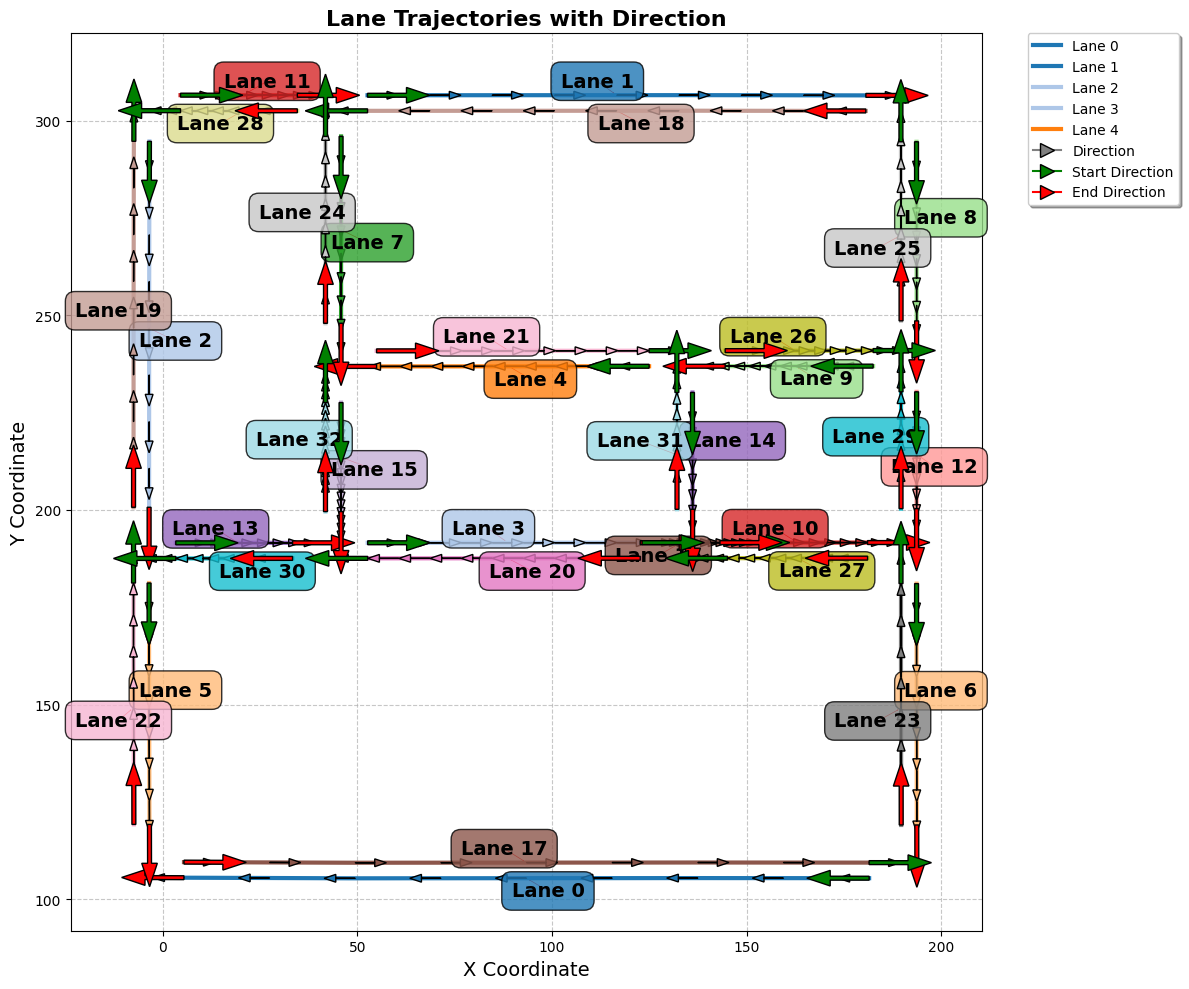

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patheffects import withStroke
from adjustText import adjust_text  # You'll need to install this: pip install adjustText

def visualize_lanes_with_labels(trajectories, figsize=(12, 10)):
    """
    Visualize lanes (trajectories) with clear labels.
    Parameters:
    - trajectories: List of trajectory objects
    - figsize: Size of the figure
    """
    plt.figure(figsize=figsize)
    # Create a colormap for the trajectories
    num_trajectories = len(trajectories)
    colors = plt.cm.tab20(np.linspace(0, 1, num_trajectories))
    
    # Prepare for text adjustment
    texts = []
    
    # Plot each trajectory with a unique color and label
    for i, trajectory in enumerate(trajectories):
        x_coords = []
        y_coords = []
        angles = []
        
        # Extract coordinates from trajectory
        for waypoint in trajectory:
            location = waypoint.transform.location
            fw = waypoint.transform.get_forward_vector()
            angle = np.arctan2(fw.y, fw.x)
            angles.append(angle)
            x_coords.append(location.x)
            y_coords.append(location.y)
            
        # Plot trajectory with unique color
        traj_color = colors[i % len(colors)]
        plt.plot(x_coords, y_coords, '-', color=traj_color, linewidth=3,
                label=f'Lane {i}')
        
        # Add direction arrows along the trajectory
        arrow_spacing = max(1, len(x_coords) // 8)  # Show arrows at regular intervals
        for j in range(0, len(x_coords), arrow_spacing):
            if j < len(angles):
                # Calculate arrow direction based on angle
                dx = np.cos(angles[j]) * 5  # Arrow length x component
                dy = np.sin(angles[j]) * 5  # Arrow length y component
                plt.arrow(x_coords[j], y_coords[j], dx, dy, 
                         head_width=2, head_length=3, fc=traj_color, ec='black',
                         zorder=3)  # Higher zorder to draw on top
        
        # Add special markers for start and end with direction arrows
        # Start point (larger green arrow)
        start_dx = np.cos(angles[0]) * 10
        start_dy = np.sin(angles[0]) * 10
        plt.arrow(x_coords[0], y_coords[0], start_dx, start_dy,
                 head_width=4, head_length=6, fc='green', ec='black',
                 width=1, zorder=4)
        
        # End point (larger red arrow)
        end_dx = np.cos(angles[-1]) * 10
        end_dy = np.sin(angles[-1]) * 10
        plt.arrow(x_coords[-1], y_coords[-1], end_dx, end_dy,
                 head_width=4, head_length=6, fc='red', ec='black',
                 width=1, zorder=4)
                 
        # Add label to the middle of the trajectory (store for later adjustment)
        mid_point = len(x_coords) // 2
        text = plt.text(x_coords[mid_point], y_coords[mid_point], f'Lane {i}',
                color='black', fontsize=14, fontweight='bold', ha='center', va='center',
                bbox=dict(facecolor=traj_color, alpha=0.8, boxstyle='round,pad=0.5',
                edgecolor='black', linewidth=1))
        texts.append(text)
    
    # Adjust text positions to avoid overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
    
    # Add labels and title
    plt.xlabel('X Coordinate', fontsize=14)
    plt.ylabel('Y Coordinate', fontsize=14)
    plt.title('Lane Trajectories with Direction', fontsize=16, fontweight='bold')
    
    # Create a custom legend
    custom_legend = []
    
    # Add legend entries
    for i in range(min(5, num_trajectories)):
        lane_line = plt.Line2D([0], [0], color=colors[i], linewidth=3, label=f'Lane {i}')
        custom_legend.append(lane_line)
        
    # Add direction indicators to legend
    direction = plt.Line2D([0], [0], marker='>', color='gray', 
                        markersize=10, markeredgecolor='black',
                        label='Direction')
    start_direction = plt.Line2D([0], [0], marker='>', color='green', 
                              markersize=10, markeredgecolor='black',
                              label='Start Direction')
    end_direction = plt.Line2D([0], [0], marker='>', color='red', 
                            markersize=10, markeredgecolor='black',
                            label='End Direction')
    
    custom_legend.extend([direction, start_direction, end_direction])
    
    # Display the legend
    plt.legend(handles=custom_legend, loc='upper left', bbox_to_anchor=(1.05, 1),
              borderaxespad=0., frameon=True, fancybox=True, shadow=True)
    
    # Add grid and make sure aspect ratio is equal
    plt.axis('equal')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

visualize_lanes_with_labels(single_lane_trajectories_1)

In [11]:
easy_trajectories=[
    [11,7],
    [18,7],
    [7,21],
    [2,13],
    [15,3]
    ]

medium_trajectories=[
    [2,13,32],
    [22,13,32],
    [17,23,27],
    [10,29,9],
    [11,7,21]
    ]

hard_trajectories=[
    [2,13,32,21],
    [7,15,3,10,6],
    [27,20,32,24],
    [13,32,21,14],
    [18,7,21,14,10]
    ]

In [12]:
def convert(waypoint):
    location=waypoint.transform.location
    rotation=waypoint.transform.rotation
    return {"location":np.array([location.x,location.y,location.z]),"rotation":np.array([
        rotation.roll,rotation.pitch,rotation.yaw
    ])}
easy_trajectories_waypoints={}
for ix,traj in enumerate(easy_trajectories):
    temp=[]
    for lane in traj:
        temp.extend(map(convert,single_lane_trajectories_1[lane]))
    easy_trajectories_waypoints[str(ix)]=temp

medium_trajectories_waypoints={}
for ix,traj in enumerate(medium_trajectories):
    temp=[]
    for lane in traj:
        temp.extend(map(convert,single_lane_trajectories_1[lane]))
    medium_trajectories_waypoints[str(ix)]=temp


hard_trajectories_waypoints={}
for ix,traj in enumerate(hard_trajectories):
    temp=[]
    for lane in traj:
        temp.extend(map(convert,single_lane_trajectories_1[lane]))
    hard_trajectories_waypoints[str(ix)]=temp

    


In [13]:
# import pickle
# with open("user_defined_trajectories.pkl","wb") as p:
#     pickle.dump(dict(easy=easy_trajectories_waypoints,medium=medium_trajectories_waypoints,hard=hard_trajectories_waypoints),p)

In [14]:
# ((140 + 222 + 296)/3)*0.67

In [15]:

# mean_nodes= ((9+11)/6 + (140 + 222 + 296)/3)/((9+11)/6)
# mean_nodes

In [24]:
import carla
import numpy as np
import time
import queue
import cv2
from datetime import datetime

def save_bird_eye_image(client, trajectory_waypoints, output_filename=None, image_size=(1920, 1080)):
    """
    Set up a camera at a bird's eye view of trajectories and save an image.
    Centers the camera at town center rather than trajectory center.
    
    Parameters:
    - client: CARLA client instance
    - trajectory_waypoints: List of waypoint dictionaries with location and rotation
    - output_filename: Name for the output image file (default: timestamp)
    - image_size: Resolution of the output image as (width, height)
    """
    world = client.get_world()
    
    # Extract coordinates for trajectory visualization
    locations = []
    for waypoint in trajectory_waypoints:
        loc = waypoint["location"]
        carla_loc = carla.Location(x=float(loc[0]), y=float(loc[1]), z=float(loc[2]))
        locations.append(carla_loc)
    
    if not locations:
        print("No trajectory points to visualize")
        return
    
    # Town02 center coordinates (approximate)
    # These are the coordinates for the center of Town02 
    town_center_x = 0
    town_center_y = 0
    town_center_z = 0
    
    # Set a fixed camera height that shows the entire town
    view_height = 200  # Meters above town center
    
    # Set up blueprint library
    blueprint_library = world.get_blueprint_library()
    
    # Get the camera sensor blueprint
    camera_bp = blueprint_library.find('sensor.camera.rgb')
    
    # Set camera attributes for higher FOV to see more of the town
    camera_bp.set_attribute('image_size_x', str(image_size[0]))
    camera_bp.set_attribute('image_size_y', str(image_size[1]))
    camera_bp.set_attribute('fov', '120')  # Wider field of view
    
    # Set up camera transform at bird's eye view over town center
    camera_transform = carla.Transform(
        carla.Location(x=town_center_x, y=town_center_y, z=town_center_z + view_height),
        carla.Rotation(pitch=-90, yaw=0, roll=0)  # Looking straight down
    )
    
    # Create a camera actor
    camera = world.spawn_actor(camera_bp, camera_transform)
    print(f"Camera positioned at height {view_height:.2f} meters above town center")
    
    # Also set spectator to same position for visualization
    spectator = world.get_spectator()
    spectator.set_transform(camera_transform)
    
    # Draw the trajectory for visualization
    debug = world.debug
    
    # Draw the trajectory line segments with higher thickness
    for i in range(len(locations) - 1):
        debug.draw_line(
            locations[i], locations[i + 1],
            thickness=1.0,  # Increased thickness
            color=carla.Color(255, 0, 0),  # Red trajectory
            life_time=20.0  # Longer lifetime
        )
    
    # Draw start and end points with larger, more visible spheres
    if locations:
        # Draw start point (green sphere)
        debug.draw_point(
            locations[0],
            size=2.0,  # Larger point
            color=carla.Color(0, 255, 0),  # Green
            life_time=20.0
        )
        
        # Draw end point (red sphere)
        debug.draw_point(
            locations[-1],
            size=2.0,  # Larger point
            color=carla.Color(255, 0, 0),  # Red
            life_time=20.0
        )
        
        # Draw intermediate points as smaller points
        for i in range(1, len(locations) - 1, 5):  # Every 5th point to avoid clutter
            debug.draw_point(
                locations[i],
                size=0.5,  # Smaller than start/end
                color=carla.Color(0, 0, 255),  # Blue
                life_time=20.0
            )
    
    # Set up a queue to capture the image
    image_queue = queue.Queue()
    
    # Callback function to save the image
    def camera_callback(image):
        image_queue.put(image)
    
    # Register the callback function
    camera.listen(camera_callback)
    
    # Generate default filename if not provided
    if output_filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_filename = f"carla_trajectory_birdeye_{timestamp}.jpg"
    
    # Wait a moment for rendering and capture the image
    print("Waiting for camera to capture image...")
    time.sleep(2.0)  # Allow more time for rendering
    
    try:
        # Get the image from the queue
        image = image_queue.get(timeout=5.0)  # Longer timeout
        
        # Convert the image to a usable format
        array = np.frombuffer(image.raw_data, dtype=np.dtype("uint8"))
        array = np.reshape(array, (image.height, image.width, 4))
        array = array[:, :, :3]  # Remove the alpha channel
        
        # Optional: Enhance image for better visibility
        # Increase brightness and contrast slightly
        array = np.clip(array * 1.2, 0, 255).astype(np.uint8)
        
        # Save the image using OpenCV
        cv2.imwrite(output_filename, array)
        print(f"Image saved as {output_filename}")
        
    except queue.Empty:
        print("Failed to capture image (timeout)")
    finally:
        # Clean up
        camera.stop()
        camera.destroy()
        print("Camera destroyed")

def visualize_multiple_trajectories(client, trajectories_dict, output_filename=None):
    """
    Visualize multiple trajectories on a single bird's eye view image.
    
    Parameters:
    - client: CARLA client instance
    - trajectories_dict: Dictionary of trajectory types and their waypoints
    - output_filename: Name for the output image file
    """
    world = client.get_world()
    
    # Town02 center coordinates
    town_center_x = 0
    town_center_y = 0
    town_center_z = 0
    
    # Set a fixed camera height that shows the entire town
    view_height = 200  # Meters above town center
    
    # Set spectator to bird's eye view position
    spectator = world.get_spectator()
    spectator_transform = carla.Transform(
        carla.Location(x=town_center_x, y=town_center_y, z=town_center_z + view_height),
        carla.Rotation(pitch=-90, yaw=0, roll=0)
    )
    spectator.set_transform(spectator_transform)
    
    # Debug drawing
    debug = world.debug
    
    # Color coding for different trajectory types
    colors = {
        "hard": carla.Color(255, 0, 0),      # Red
        "medium": carla.Color(0, 255, 0),    # Green
        "easy": carla.Color(0, 0, 255)       # Blue
    }
    
    # Draw each type of trajectory
    for traj_type, traj_dict in trajectories_dict.items():
        color = colors.get(traj_type, carla.Color(255, 255, 255))
        
        for traj_id, waypoints in traj_dict.items():
            locations = []
            for waypoint in waypoints:
                loc = waypoint["location"]
                carla_loc = carla.Location(x=float(loc[0]), y=float(loc[1]), z=float(loc[2]))
                locations.append(carla_loc)
            
            if not locations:
                continue
                
            # Draw trajectory lines
            for i in range(len(locations) - 1):
                debug.draw_line(
                    locations[i], locations[i + 1],
                    thickness=1.0,
                    color=color,
                    life_time=30.0
                )
            
            # Mark start and end points
            debug.draw_point(locations[0], size=2.0, color=carla.Color(0, 255, 0), life_time=30.0)
            debug.draw_point(locations[-1], size=2.0, color=carla.Color(255, 0, 0), life_time=30.0)
            
            # Add text label for trajectory ID
            mid_point = locations[len(locations) // 2]
            debug.draw_string(mid_point, f"{traj_type} {traj_id}", draw_shadow=True, 
                             color=carla.Color(255, 255, 255), life_time=30.0)
    
    # Set up camera to capture the image
    blueprint_library = world.get_blueprint_library()
    camera_bp = blueprint_library.find('sensor.camera.rgb')
    camera_bp.set_attribute('image_size_x', str(1920))
    camera_bp.set_attribute('image_size_y', str(1080))
    camera_bp.set_attribute('fov', '120')
    
    camera = world.spawn_actor(camera_bp, spectator_transform)
    
    # Set up a queue to capture the image
    image_queue = queue.Queue()
    camera.listen(lambda image: image_queue.put(image))
    
    # Generate default filename if not provided
    if output_filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_filename = f"carla_all_trajectories_{timestamp}.jpg"
    
    # Wait for rendering
    print("Waiting for camera to capture all trajectories...")
    time.sleep(3.0)
    
    try:
        image = image_queue.get(timeout=5.0)
        array = np.frombuffer(image.raw_data, dtype=np.dtype("uint8"))
        array = np.reshape(array, (image.height, image.width, 4))
        array = array[:, :, :3]
        
        # Enhance visibility
        array = np.clip(array * 1.2, 0, 255).astype(np.uint8)
        
        cv2.imwrite(output_filename, array)
        print(f"Composite image saved as {output_filename}")
        
    except queue.Empty:
        print("Failed to capture image (timeout)")
    finally:
        camera.stop()
        camera.destroy()

# Example usage:
def capture_all_trajectories():
    # Connect to CARLA server
    client = carla.Client('localhost', 2000)
    client.set_timeout(10.0)
    
    print("Connected to CARLA server")
    
    # Visualize a single hard trajectory first
    if hard_trajectories_waypoints:
        traj_id = list(hard_trajectories_waypoints.keys())[0]
        output_file = f"hard_trajectory_{traj_id}_birdeye.jpg"
        print(f"Capturing bird's eye view for hard trajectory {traj_id}...")
        save_bird_eye_image(client, hard_trajectories_waypoints[traj_id], output_file)
    
    # Visualize all trajectories on one image
    print("Creating composite view of all trajectories...")
    trajectories_dict = {
        "hard": hard_trajectories_waypoints,
        "medium": medium_trajectories_waypoints,
        "easy": easy_trajectories_waypoints
    }
    visualize_multiple_trajectories(client, trajectories_dict, "all_trajectories_birdeye.jpg")
    
    print("All trajectory images captured")

# if __name__ == "__main__":
capture_all_trajectories()

Connected to CARLA server
Capturing bird's eye view for hard trajectory 0...
Camera positioned at height 200.00 meters above town center
Waiting for camera to capture image...
Image saved as hard_trajectory_0_birdeye.jpg
Camera destroyed
Creating composite view of all trajectories...
Waiting for camera to capture all trajectories...
Composite image saved as all_trajectories_birdeye.jpg
All trajectory images captured
